# Solute Transport Toy: P=100 serial vs parallel

Minimal notebook for comparing serial and parallel mPCN runs at P=100.

## Setup

Imports and repository resolution.

In [1]:
import os
from pathlib import Path
import time
import json
import hashlib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.effective_sample_size import (
    estimate_effective_sample_size,
    summarize_squared_jumping_distance,
 )
from multiproposal.utils.run_paths import format_float_tag

In [2]:
# Data configuration (from solute transport toy notebook)
seed_data = 0
seed_mcmc = 0

d = 10
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data

obs_highest_freq = 6
obs_bandwidth = 3
obs_config = 'central_modes'

print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

d: 10
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
if isinstance(obs_config, dict):
    obs_config_serializable = {
        key: (val.tolist() if isinstance(val, np.ndarray) else val)
        for key, val in obs_config.items()
    }
else:
    obs_config_serializable = obs_config
data_id_config = {
    'seed_data': seed_data,
    'seed_mcmc': seed_mcmc,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config_serializable,
}
data_config = dict(data_id_config)
data_config.update({
    'd': d,
})

In [4]:
# Comparison configuration
n_iters = 30000
seed_base = 202
max_lag = 1500
burn_in = 5000

# Parallel execution defaults (used for check-parallel runs)
mpcn_parallel_n_jobs = 1
mpcn_parallel_backend = 'auto'
mpcn_parallelize_props = False
mpcn_llh_chunk_size = 0

# Optional overrides to reuse an existing run directory exactly.
data_id_override = 'data_h5d92590a6971'
run_id_override = 'mpcn_rho_sweep_h0546a8b4ce54'

def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode('utf-8')
    return hashlib.sha256(data).hexdigest()[:length]

data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_rho_sweep_h{_stable_hash({
    'algorithm': 'mpcn_rho_sweep',
    'algorithm_config': {
        'n_iters': n_iters,
        'burn_in': burn_in,
        'max_lag': max_lag,
    },
    'sweep': {
        'seed_base': seed_base,
    },
})}"
estimations_dir = repo_root / 'estimations' / 'solute_transport' / data_id / 'sweep' / run_id
reports_dir = repo_root / 'reports' / 'solute_transport' / data_id / 'sweep' / run_id
for path in (estimations_dir, reports_dir):
    path.mkdir(parents=True, exist_ok=True)

print('Run directory:', estimations_dir)

Run directory: /home/senng/multiproposal-internal/estimations/solute_transport/data_h5d92590a6971/sweep/mpcn_rho_sweep_h0546a8b4ce54


In [5]:
# Shared-draws helpers
def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]

def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
 ):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}')
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset)
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1)
        ,
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }

def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }

def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
 )
problem, a_init, data = build_problem_for_dim(d, shared_draws)
x0 = a_init.copy()

print('Shared draws ready with d:', d)
print('Initial x0 norm:', np.linalg.norm(x0))

Shared draws ready with d: 10
Initial x0 norm: 0.12192810032786688


In [6]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag, include_msjd_distribution=False, parallel_info=None):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    msjd_summary = summarize_squared_jumping_distance(
        post,
        percentiles=(0.5, 2.5, 50.0, 97.5, 99.5),
        return_distribution=include_msjd_distribution,
    )
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'msjd_summary': msjd_summary,
        'ess_per_min': ess_per_min,
        'ess_per_param': ess_vals.tolist(),
        'msjd_per_param': msjd_vals.tolist(),
        'parallel': parallel_info,
    }

def rho_to_tag(rho):
    return format_float_tag(rho)

def chain_cache_paths(method, rho, seed_base, P=None):
    rho_tag = rho_to_tag(rho)
    if P is None:
        stem = f"{method}_rho{rho_tag}_seed{seed_base}"
    else:
        stem = f"{method}_P{P}_rho{rho_tag}_seed{seed_base}"
    chains_dir = estimations_dir / 'chains'
    samples_path = chains_dir / f"{stem}.npz"
    metrics_path = chains_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path

def save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec):
    payload = dict(metrics)
    payload['accept_rate'] = None if accept_rate is None else float(accept_rate)
    payload['runtime_sec'] = float(runtime_sec)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

def save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics):
    samples_path.parent.mkdir(parents=True, exist_ok=True)
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )
    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)

def load_chain_bundle(samples_path, metrics_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    metrics = load_metrics_json(metrics_path)
    return chain, accept_rate, runtime_sec, metrics

def run_mpcn_chain(
    problem,
    x0,
    n_iters,
    rho,
    n_props,
    seed,
    diag_indices=None,
    parallel_backend='process',
    n_jobs=1,
    parallelize_props=False,
    llh_chunk_size=None,
 ):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, _ = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
            n_jobs=n_jobs,
            parallel_backend=parallel_backend,
            parallelize_props=parallelize_props,
            llh_chunk_size=llh_chunk_size,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            n_jobs=n_jobs,
            parallel_backend=parallel_backend,
            parallelize_props=parallelize_props,
            llh_chunk_size=llh_chunk_size,
        )
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, None

In [7]:
# Check parallel mPCN for P=100 (separate cache)
P_check_parallel = 100
rho_check_parallel = [0.0, 0.4, 0.6, 0.95]

check_parallel_dir = estimations_dir / 'chains' / 'check_parallel'
check_parallel_dir.mkdir(parents=True, exist_ok=True)

def check_parallel_cache_paths(P, rho, seed_base):
    rho_tag = rho_to_tag(rho)
    stem = f"mpcn_P{P}_rho{rho_tag}_seed{seed_base}"
    samples_path = check_parallel_dir / f"{stem}.npz"
    metrics_path = check_parallel_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path

check_parallel_n_jobs = mpcn_parallel_n_jobs if mpcn_parallel_n_jobs > 1 else 2
check_parallel_backend = 'process'
check_parallel_parallelize_props = False
check_parallel_llh_chunk_size = mpcn_llh_chunk_size

check_parallel_results = {}
for rho in rho_check_parallel:
    samples_path, metrics_path = check_parallel_cache_paths(P_check_parallel, rho, seed_base)
    loaded = load_chain_bundle(samples_path, metrics_path)
    if loaded is not None:
        chain, accept_rate, runtime_sec, metrics = loaded
        if metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag,
                parallel_info={
                    'backend': check_parallel_backend,
                    'n_jobs': check_parallel_n_jobs,
                    'parallelize_props': check_parallel_parallelize_props,
                    'llh_chunk_size': check_parallel_llh_chunk_size,
                },
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        check_parallel_results[float(rho)] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'check_parallel loaded: P={P_check_parallel}, rho={rho:.3f}, '
            f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )
        continue
    seed = seed_base + int(P_check_parallel * 1000 + round(rho * 100))

    if check_parallel_llh_chunk_size and check_parallel_llh_chunk_size > 0:
        llh_chunk_size = int(check_parallel_llh_chunk_size)
    else:
        llh_chunk_size = max(1, int(np.ceil(P_check_parallel / max(1, check_parallel_n_jobs))))

    chain, runtime_sec, accept_rate, _ = run_mpcn_chain(
        problem,
        x0,
        n_iters,
        rho=rho,
        n_props=P_check_parallel,
        seed=seed,
        diag_indices=None,
        parallel_backend=check_parallel_backend,
        n_jobs=check_parallel_n_jobs,
        parallelize_props=check_parallel_parallelize_props,
        llh_chunk_size=llh_chunk_size,
    )
    metrics = summarize_chain_metrics(
        chain,
        runtime_sec,
        burn_in=burn_in,
        max_lag=max_lag,
        parallel_info={
            'backend': check_parallel_backend,
            'n_jobs': check_parallel_n_jobs,
            'parallelize_props': check_parallel_parallelize_props,
            'llh_chunk_size': llh_chunk_size,
        },
    )
    save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
    check_parallel_results[float(rho)] = {
        'chain': chain,
        'runtime_sec': runtime_sec,
        'accept_rate': accept_rate,
        'metrics': metrics,
    }
    print(
        f'check_parallel done: P={P_check_parallel}, rho={rho:.3f}, '
        f'accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s'
    )

# Check parallel mPCN for P=100 with a different seed base and longer chains
seed_base_check_parallel_alt = seed_base + 999
n_iters_check_parallel_alt = 100000

check_parallel_alt_results = {}
for rho in rho_check_parallel:
    samples_path, metrics_path = check_parallel_cache_paths(
        P_check_parallel, rho, seed_base_check_parallel_alt
    )
    loaded = load_chain_bundle(samples_path, metrics_path)
    if loaded is not None:
        chain, accept_rate, runtime_sec, metrics = loaded
        if metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag,
                parallel_info={
                    'backend': check_parallel_backend,
                    'n_jobs': check_parallel_n_jobs,
                    'parallelize_props': check_parallel_parallelize_props,
                    'llh_chunk_size': check_parallel_llh_chunk_size,
                },
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        check_parallel_alt_results[float(rho)] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'check_parallel_alt loaded: P={P_check_parallel}, rho={rho:.3f}, '
            f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )
        continue
    seed = seed_base_check_parallel_alt + int(P_check_parallel * 1000 + round(rho * 100))

    if check_parallel_llh_chunk_size and check_parallel_llh_chunk_size > 0:
        llh_chunk_size = int(check_parallel_llh_chunk_size)
    else:
        llh_chunk_size = max(1, int(np.ceil(P_check_parallel / max(1, check_parallel_n_jobs))))

    chain, runtime_sec, accept_rate, _ = run_mpcn_chain(
        problem,
        x0,
        n_iters_check_parallel_alt,
        rho=rho,
        n_props=P_check_parallel,
        seed=seed,
        diag_indices=None,
        parallel_backend=check_parallel_backend,
        n_jobs=check_parallel_n_jobs,
        parallelize_props=check_parallel_parallelize_props,
        llh_chunk_size=llh_chunk_size,
    )
    metrics = summarize_chain_metrics(
        chain,
        runtime_sec,
        burn_in=burn_in,
        max_lag=max_lag,
        parallel_info={
            'backend': check_parallel_backend,
            'n_jobs': check_parallel_n_jobs,
            'parallelize_props': check_parallel_parallelize_props,
            'llh_chunk_size': llh_chunk_size,
        },
    )
    save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
    check_parallel_alt_results[float(rho)] = {
        'chain': chain,
        'runtime_sec': runtime_sec,
        'accept_rate': accept_rate,
        'metrics': metrics,
    }
    print(
        f'check_parallel_alt done: P={P_check_parallel}, rho={rho:.3f}, '
        f'accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s'
    )

check_parallel loaded: P=100, rho=0.000, accept=0.012, runtime=54.98s
check_parallel loaded: P=100, rho=0.400, accept=0.018, runtime=56.23s
check_parallel loaded: P=100, rho=0.600, accept=0.032, runtime=55.60s
check_parallel loaded: P=100, rho=0.950, accept=0.301, runtime=53.83s
check_parallel_alt loaded: P=100, rho=0.000, accept=0.012, runtime=177.44s
check_parallel_alt loaded: P=100, rho=0.400, accept=0.018, runtime=181.02s
check_parallel_alt loaded: P=100, rho=0.600, accept=0.030, runtime=179.19s
check_parallel_alt loaded: P=100, rho=0.950, accept=0.313, runtime=183.02s


check_serial loaded: P=100, rho=0.000, accept=0.012, runtime=405.05s
check_serial loaded: P=100, rho=0.400, accept=0.018, runtime=402.81s
check_serial loaded: P=100, rho=0.600, accept=0.031, runtime=401.45s
check_serial loaded: P=100, rho=0.950, accept=0.310, runtime=406.98s
Serial vs check-serial vs parallel (P=100): ESS/MSJD means


,rho,run,n_iters,accept_rate,runtime_sec,ess_mean,msjd_mean
1,0.00,check_serial,300000,0.012333,405.045308,1183.503270,0.000011
2,0.00,parallel,30000,0.012033,54.977259,103.916015,0.000011
3,0.00,parallel_alt,100000,0.012160,177.440274,434.761617,0.000011
0,0.00,serial,300000,0.012333,397.118400,1183.503270,0.000011
5,0.40,check_serial,300000,0.018373,402.811498,1601.190787,0.000015
6,0.40,parallel,30000,0.018367,56.231732,132.420421,0.000015
7,0.40,parallel_alt,100000,0.018000,181.021233,520.864987,0.000015
4,0.40,serial,300000,0.018373,403.997098,1601.190787,0.000015
9,0.60,check_serial,300000,0.030777,401.446134,2025.772631,0.000021
10,0.60,parallel,30000,0.031567,55.596151,203.330125,0.000021


Serial vs check-serial vs parallel (P=100): ESS/MSJD per-parameter (params 0,1)


,rho,run,ess_p0,ess_p1,msjd_p0,msjd_p1
1,0.00,check_serial,1026.621705,1118.176253,0.000231,0.000111
2,0.00,parallel,64.966217,151.701745,0.000203,0.000125
3,0.00,parallel_alt,330.693488,427.187451,0.000224,0.000107
0,0.00,serial,1026.621705,1118.176253,0.000231,0.000111
5,0.40,check_serial,1852.079316,1462.776386,0.000331,0.000142
6,0.40,parallel,178.378849,66.580699,0.000328,0.000134
7,0.40,parallel_alt,667.945758,600.371921,0.000320,0.000151
4,0.40,serial,1852.079316,1462.776386,0.000331,0.000142
9,0.60,check_serial,2630.358966,1924.915722,0.000495,0.000196
10,0.60,parallel,209.931148,224.724537,0.000511,0.000202


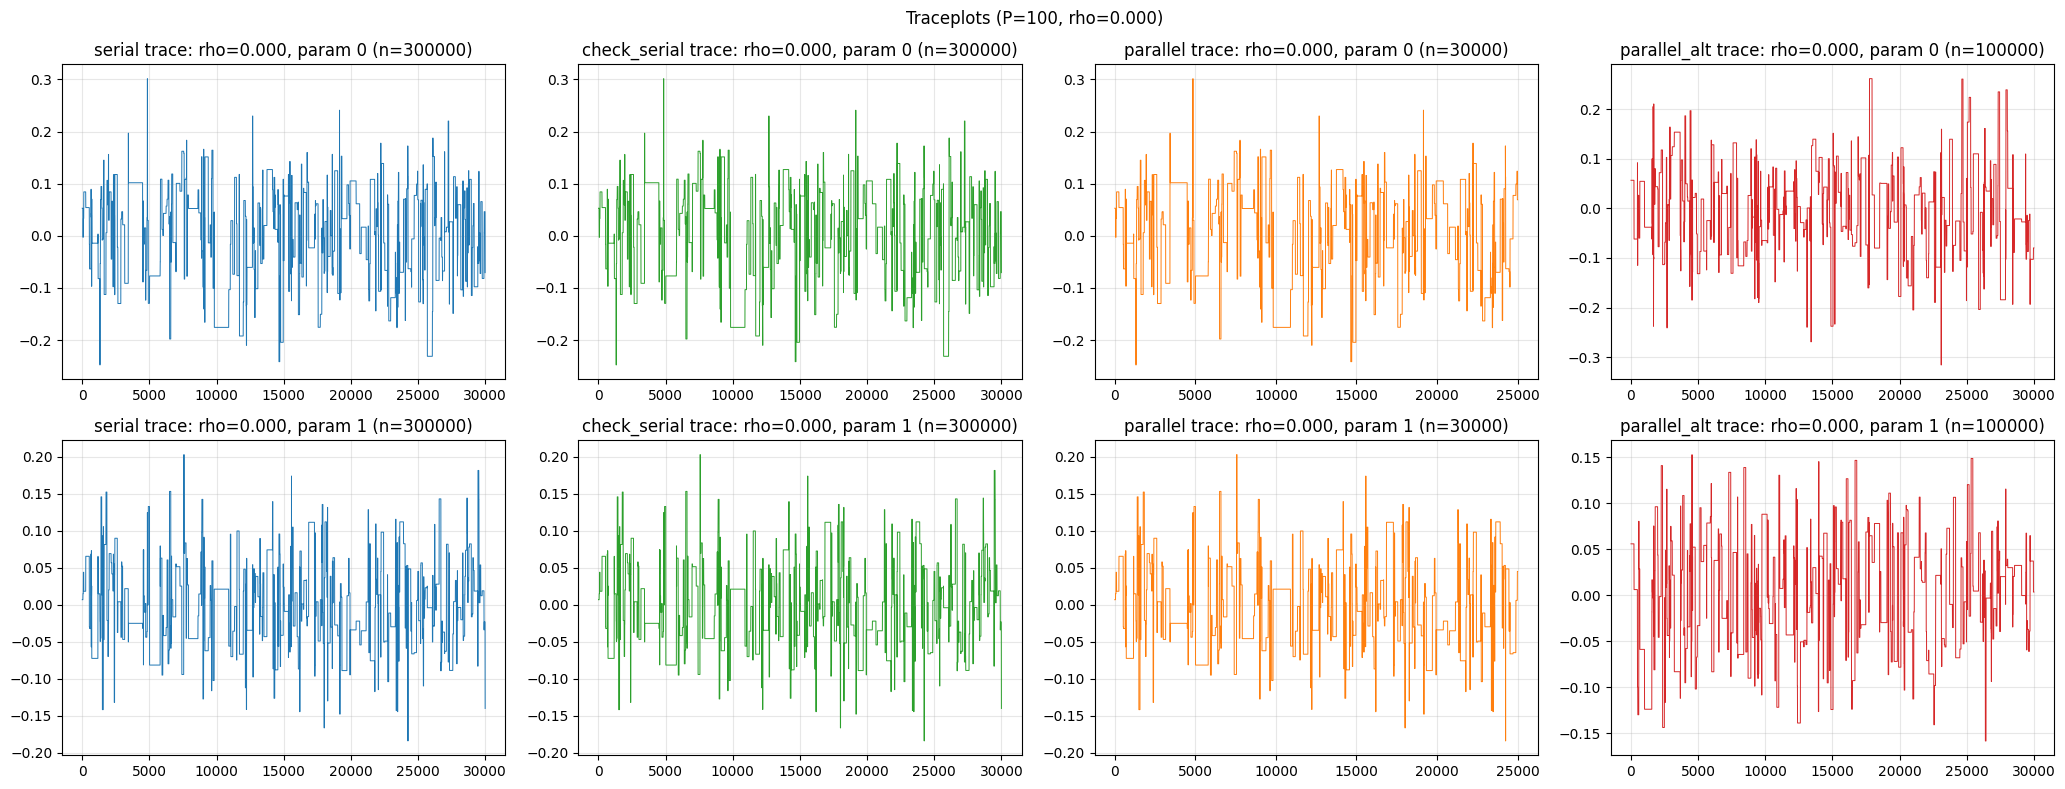

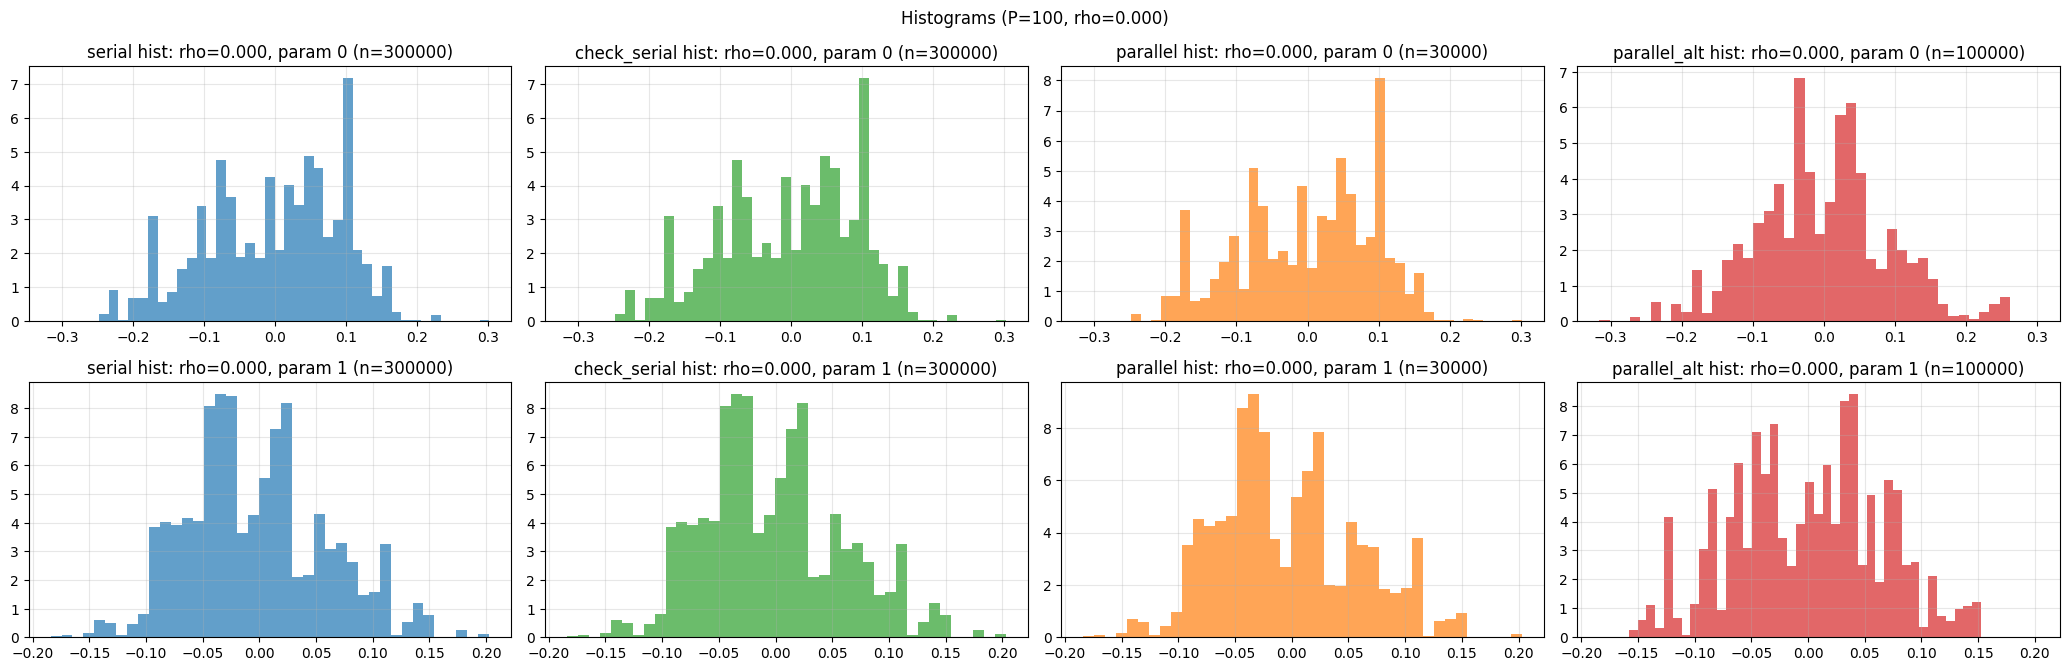

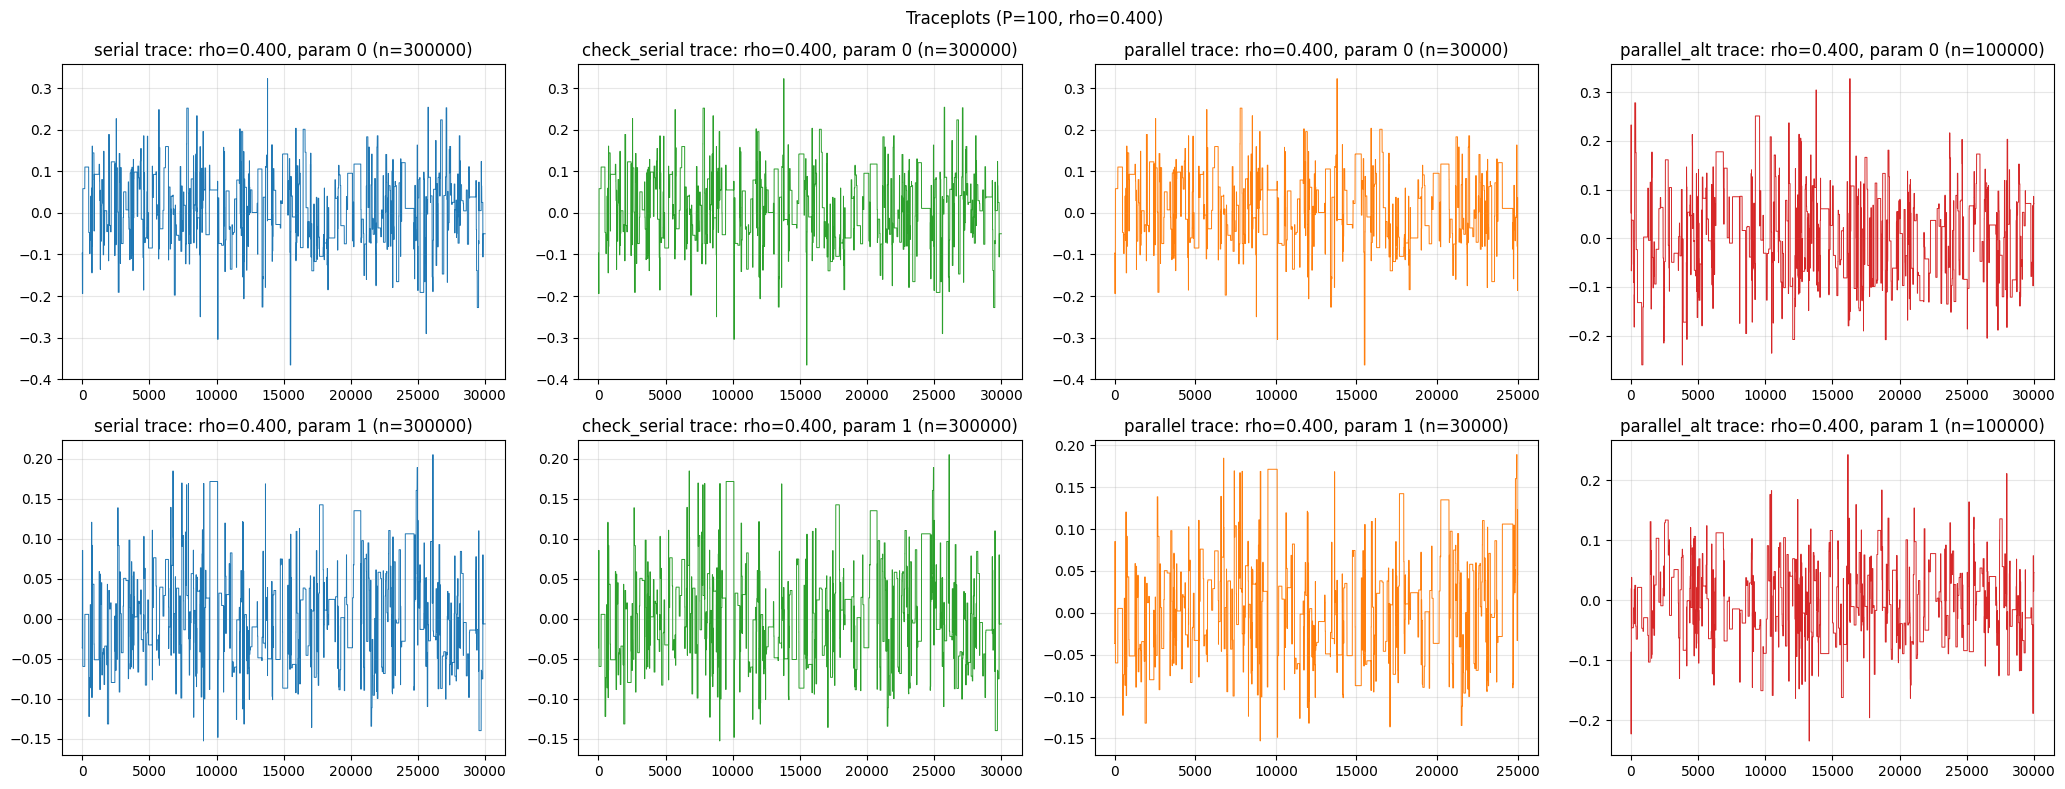

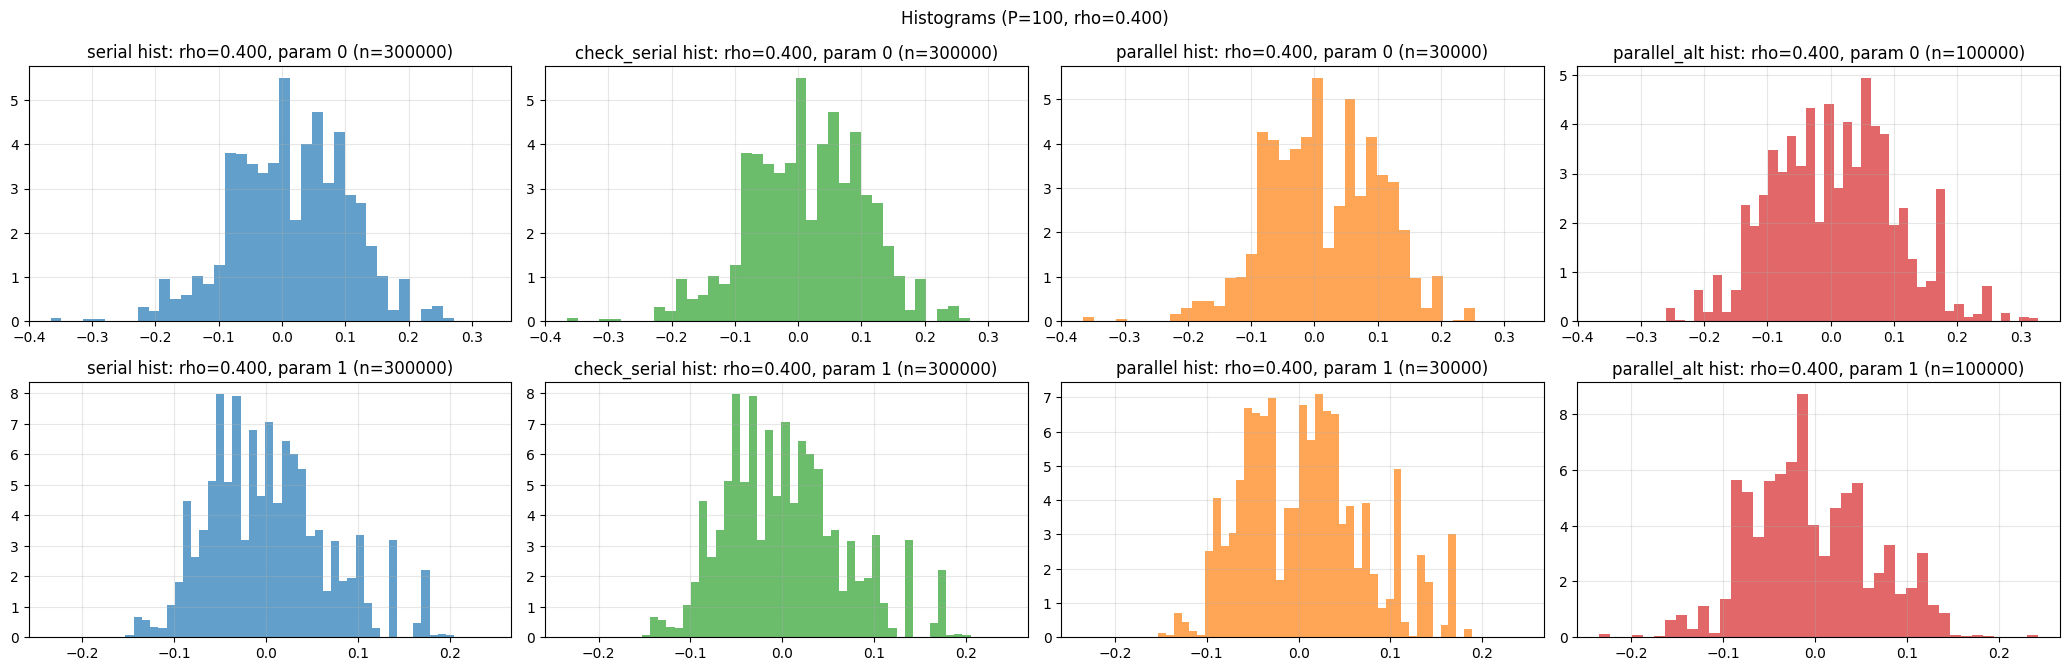

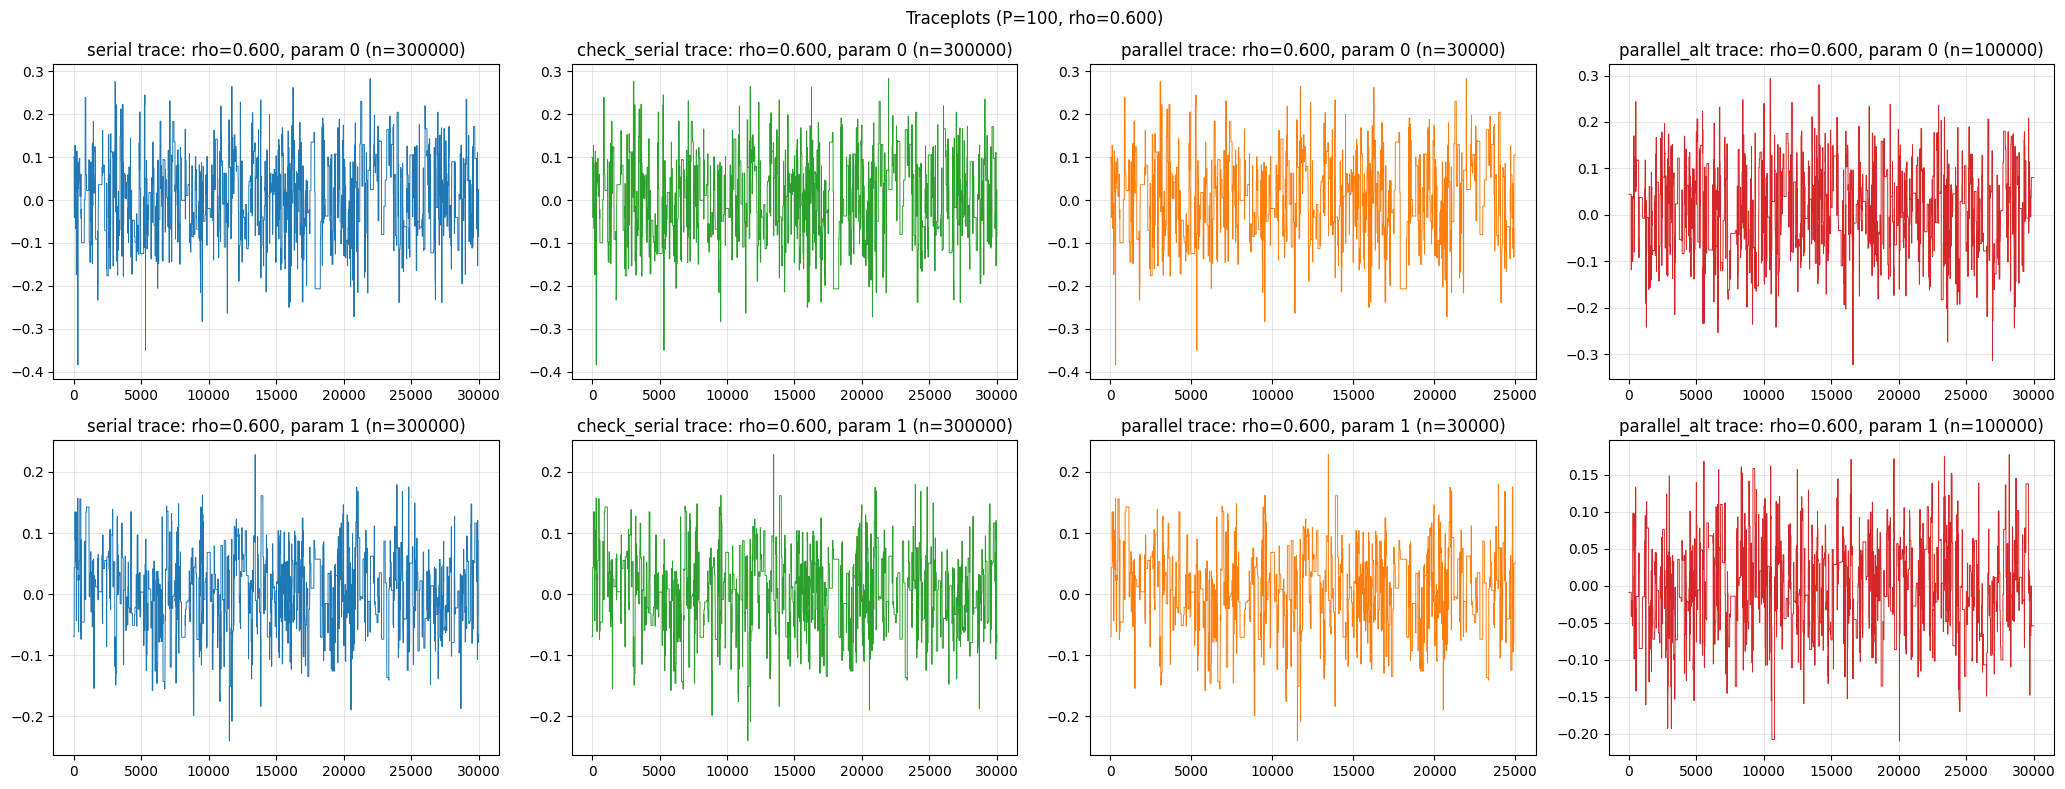

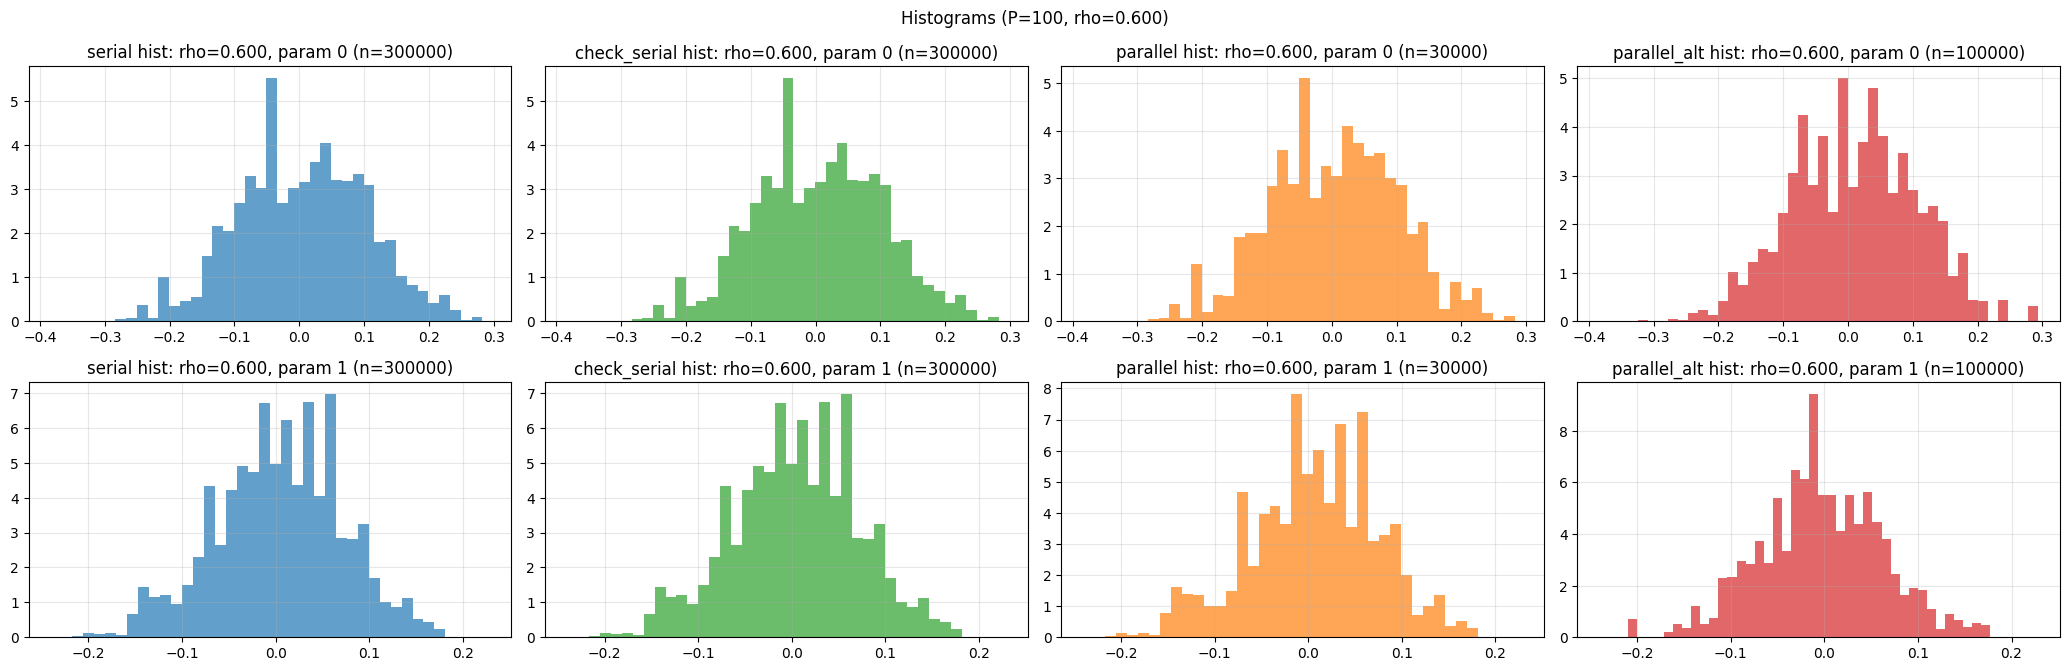

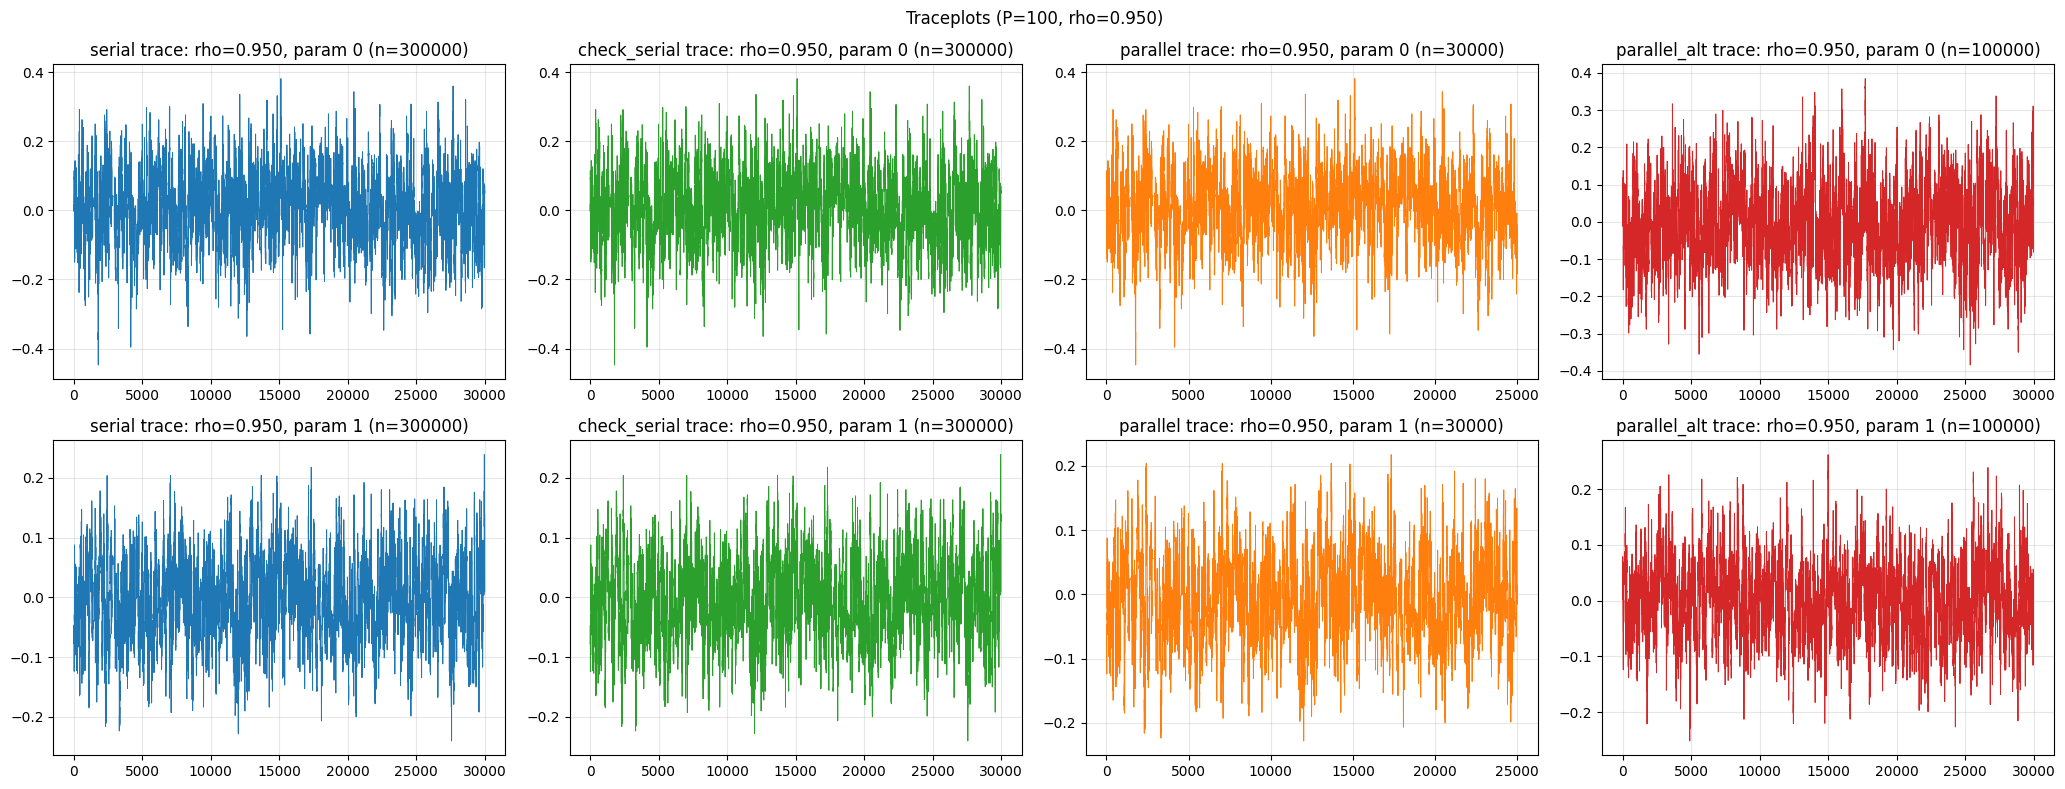

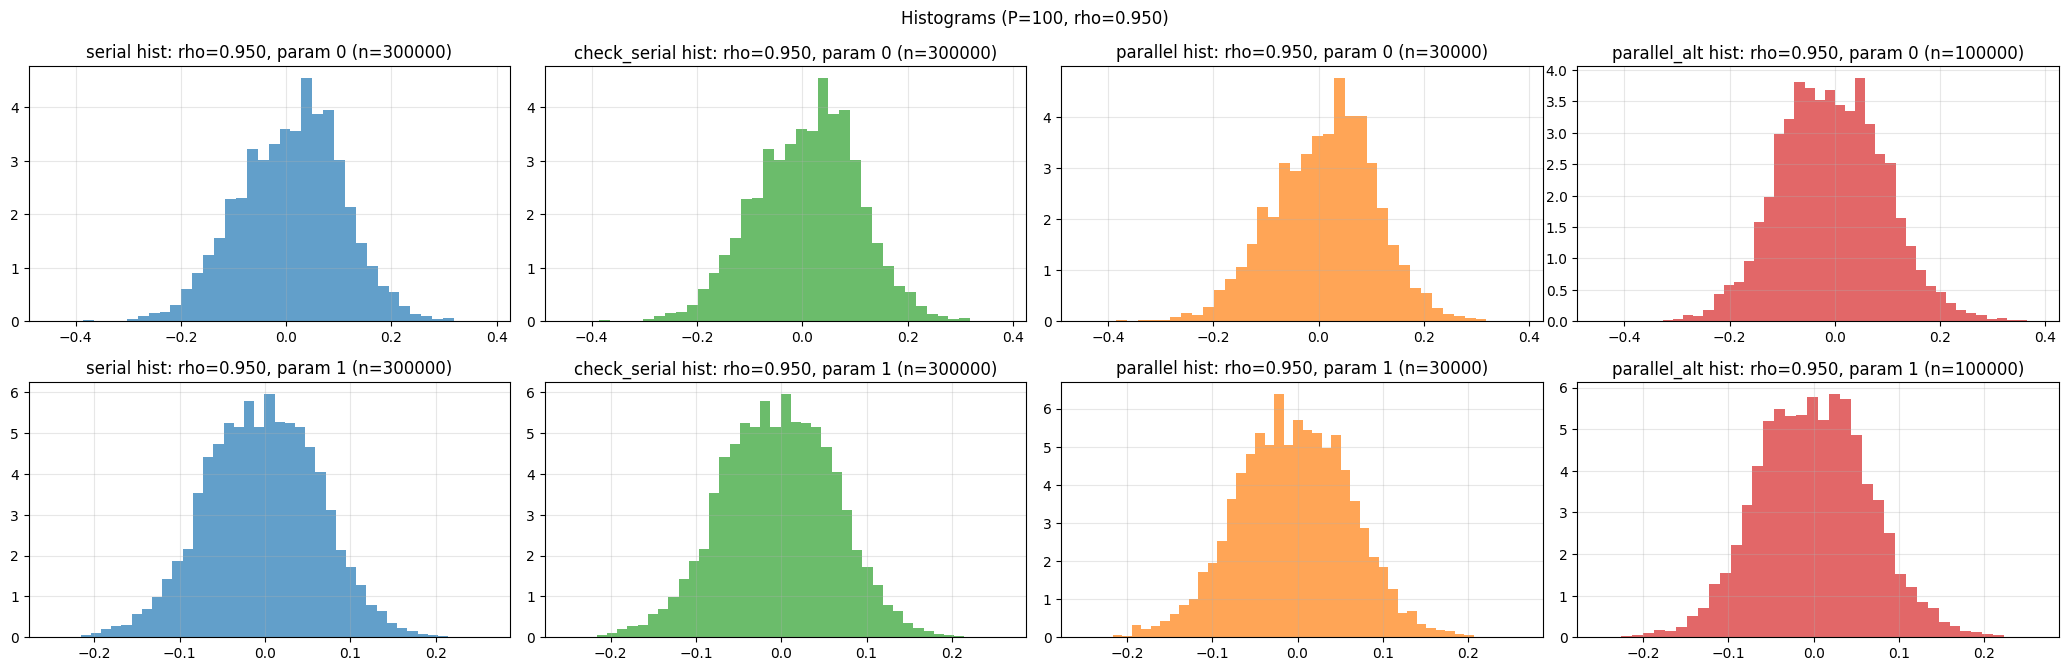

In [8]:
# Compare the parallel and the serial runs for P=100'
P_compare = P_check_parallel
rho_compare = rho_check_parallel

# Check serial mPCN for P=100 (separate cache)
P_check_serial = P_compare
rho_check_serial = rho_compare
n_iters_check_serial = 300000
force_check_serial = False

check_serial_dir = estimations_dir / 'chains' / 'check_serial'
check_serial_dir.mkdir(parents=True, exist_ok=True)

def check_serial_cache_paths(P, rho, seed_base):
    rho_tag = rho_to_tag(rho)
    stem = f"mpcn_P{P}_rho{rho_tag}_seed{seed_base}"
    samples_path = check_serial_dir / f"{stem}.npz"
    metrics_path = check_serial_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path

check_serial_results = {}
for rho in rho_check_serial:
    samples_path, metrics_path = check_serial_cache_paths(P_check_serial, rho, seed_base)
    loaded = None if force_check_serial else load_chain_bundle(samples_path, metrics_path)
    if loaded is not None:
        chain, accept_rate, runtime_sec, metrics = loaded
        if metrics is None or 'ess_per_param' not in metrics:
            metrics = summarize_chain_metrics(
                chain, runtime_sec, burn_in=burn_in, max_lag=max_lag,
                parallel_info={
                    'backend': 'serial',
                    'n_jobs': 1,
                    'parallelize_props': False,
                    'llh_chunk_size': None,
                },
            )
            save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
        check_serial_results[float(rho)] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        accept_display = np.nan if accept_rate is None else accept_rate
        print(
            f'check_serial loaded: P={P_check_serial}, rho={rho:.3f}, '
            f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
        )
        continue
    seed = seed_base + int(P_check_serial * 1000 + round(rho * 100))
    chain, runtime_sec, accept_rate, _ = run_mpcn_chain(
        problem,
        x0,
        n_iters_check_serial,
        rho=rho,
        n_props=P_check_serial,
        seed=seed,
        diag_indices=None,
        parallel_backend='thread',
        n_jobs=1,
        parallelize_props=False,
        llh_chunk_size=None,
    )
    metrics = summarize_chain_metrics(
        chain,
        runtime_sec,
        burn_in=burn_in,
        max_lag=max_lag,
        parallel_info={
            'backend': 'serial',
            'n_jobs': 1,
            'parallelize_props': False,
            'llh_chunk_size': None,
        },
    )
    save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
    check_serial_results[float(rho)] = {
        'chain': chain,
        'runtime_sec': runtime_sec,
        'accept_rate': accept_rate,
        'metrics': metrics,
    }
    print(
        f'check_serial done: P={P_check_serial}, rho={rho:.3f}, '
        f'accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s'
    )

def _load_serial_bundle(P, rho, seed_base):
    samples_path, metrics_path = chain_cache_paths('mpcn', rho=rho, seed_base=seed_base, P=P)
    return load_chain_bundle(samples_path, metrics_path)

def _load_check_serial_bundle(P, rho, seed_base):
    samples_path, metrics_path = check_serial_cache_paths(P, rho, seed_base)
    return load_chain_bundle(samples_path, metrics_path)

def _load_parallel_bundle(P, rho, seed_base):
    samples_path, metrics_path = check_parallel_cache_paths(P, rho, seed_base)
    return load_chain_bundle(samples_path, metrics_path)

def _load_parallel_alt_bundle(P, rho, seed_base):
    samples_path, metrics_path = check_parallel_cache_paths(P, rho, seed_base)
    return load_chain_bundle(samples_path, metrics_path)

def _ensure_metrics(bundle, parallel_info=None):
    if bundle is None:
        return None
    chain, accept_rate, runtime_sec, metrics = bundle
    if metrics is None or 'ess_per_param' not in metrics:
        metrics = summarize_chain_metrics(
            chain, runtime_sec, burn_in=burn_in, max_lag=max_lag, parallel_info=parallel_info
        )
    return chain, accept_rate, runtime_sec, metrics

serial_parallel = {}
for rho in rho_compare:
    serial_bundle = _load_serial_bundle(P_compare, rho, seed_base)
    check_serial_bundle = _load_check_serial_bundle(P_compare, rho, seed_base)
    parallel_bundle = _load_parallel_bundle(P_compare, rho, seed_base)
    parallel_alt_bundle = _load_parallel_alt_bundle(P_compare, rho, seed_base_check_parallel_alt)
    serial = _ensure_metrics(
        serial_bundle,
        parallel_info={
            'backend': 'serial',
            'n_jobs': 1,
            'parallelize_props': False,
            'llh_chunk_size': None,
        },
    )
    check_serial = _ensure_metrics(
        check_serial_bundle,
        parallel_info={
            'backend': 'serial',
            'n_jobs': 1,
            'parallelize_props': False,
            'llh_chunk_size': None,
        },
    )
    parallel = _ensure_metrics(
        parallel_bundle,
        parallel_info={
            'backend': check_parallel_backend,
            'n_jobs': check_parallel_n_jobs,
            'parallelize_props': check_parallel_parallelize_props,
            'llh_chunk_size': check_parallel_llh_chunk_size,
        },
    )
    parallel_alt = _ensure_metrics(
        parallel_alt_bundle,
        parallel_info={
            'backend': check_parallel_backend,
            'n_jobs': check_parallel_n_jobs,
            'parallelize_props': check_parallel_parallelize_props,
            'llh_chunk_size': check_parallel_llh_chunk_size,
        },
    )
    serial_parallel[float(rho)] = {
        'serial': serial,
        'check_serial': check_serial,
        'parallel': parallel,
        'parallel_alt': parallel_alt,
    }

mean_rows = []
param_rows = []
for rho in rho_compare:
    bundles = serial_parallel.get(float(rho), {})
    for label in ('serial', 'check_serial', 'parallel', 'parallel_alt'):
        bundle = bundles.get(label)
        if bundle is None:
            continue
        chain, accept_rate, runtime_sec, metrics = bundle
        n_iters_chain = int(chain.shape[0] - 1)
        mean_rows.append({
            'rho': float(rho),
            'run': label,
            'n_iters': n_iters_chain,
            'accept_rate': accept_rate,
            'runtime_sec': runtime_sec,
            'ess_mean': metrics.get('ess_mean', np.nan),
            'msjd_mean': metrics.get('msjd_mean', np.nan),
        })
        ess_per = metrics.get('ess_per_param', [])
        msjd_per = metrics.get('msjd_per_param', [])
        param_rows.append({
            'rho': float(rho),
            'run': label,
            'ess_p0': ess_per[0] if len(ess_per) > 0 else np.nan,
            'ess_p1': ess_per[1] if len(ess_per) > 1 else np.nan,
            'msjd_p0': msjd_per[0] if len(msjd_per) > 0 else np.nan,
            'msjd_p1': msjd_per[1] if len(msjd_per) > 1 else np.nan,
        })

mean_table = pd.DataFrame(mean_rows).sort_values(['rho', 'run'])
param_table = pd.DataFrame(param_rows).sort_values(['rho', 'run'])
print('Serial vs check-serial vs parallel (P=100): ESS/MSJD means')
display(mean_table)
print('Serial vs check-serial vs parallel (P=100): ESS/MSJD per-parameter (params 0,1)')
display(param_table)

# Traceplots and histograms for params 0 and 1
params_plot = [0, 1]
run_order = [
    ('serial', 'tab:blue'),
    ('check_serial', 'tab:green'),
    ('parallel', 'tab:orange'),
    ('parallel_alt', 'tab:red'),
 ]
for rho in rho_compare:
    bundles = serial_parallel.get(float(rho), {})
    if not any(bundles.get(label) is not None for label, _ in run_order):
        print(f'Skipping rho={rho:.3f}; missing all chains.')
        continue
    # Traceplots
    fig, axes = plt.subplots(
        len(params_plot),
        len(run_order),
        figsize=(5.2 * len(run_order), 4.0 * len(params_plot)),
        sharex=False,
    )
    if len(params_plot) == 1:
        axes = np.array([axes])
    for row_idx, param_idx in enumerate(params_plot):
        for col_idx, (label, color) in enumerate(run_order):
            bundle = bundles.get(label)
            ax = axes[row_idx, col_idx]
            if bundle is None:
                ax.axis('off')
                ax.set_title(f'{label}: missing')
                continue
            chain = bundle[0][burn_in:]
            n_iters_chain = int(bundle[0].shape[0] - 1)
            vals = chain[:, param_idx][:30000]
            ax.plot(vals, linewidth=0.7, color=color)
            ax.set_title(
                f'{label} trace: rho={rho:.3f}, param {param_idx} (n={n_iters_chain})'
            )
            ax.grid(alpha=0.3)
    fig.suptitle(f'Traceplots (P={P_compare}, rho={rho:.3f})')
    fig.tight_layout()
    fig.savefig(
        reports_dir
        / f'solute_transport_trace_serial_check_serial_parallel_P{P_compare}_rho{rho:.3f}_seed{seed_base}.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()

    # Histograms
    fig, axes = plt.subplots(
        len(params_plot),
        len(run_order),
        figsize=(5.2 * len(run_order), 3.4 * len(params_plot)),
        sharex='row',
    )
    if len(params_plot) == 1:
        axes = np.array([axes])
    for row_idx, param_idx in enumerate(params_plot):
        for col_idx, (label, color) in enumerate(run_order):
            bundle = bundles.get(label)
            ax = axes[row_idx, col_idx]
            if bundle is None:
                ax.axis('off')
                ax.set_title(f'{label}: missing')
                continue
            chain = bundle[0][burn_in:]
            n_iters_chain = int(bundle[0].shape[0] - 1)
            vals = chain[:, param_idx][:30000]
            ax.hist(vals, bins=40, density=True, alpha=0.7, color=color)
            ax.set_title(
                f'{label} hist: rho={rho:.3f}, param {param_idx} (n={n_iters_chain})'
            )
            ax.grid(alpha=0.3)
    fig.suptitle(f'Histograms (P={P_compare}, rho={rho:.3f})')
    fig.tight_layout()
    fig.savefig(
        reports_dir
        / f'solute_transport_hist_serial_check_serial_parallel_P{P_compare}_rho{rho:.3f}_seed{seed_base}.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()